# Comparación de centralidades y distribución de grados

Importamos las librerías.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## GOT

Construimos la red del primer ejemplo.

In [2]:
G=nx.Graph()

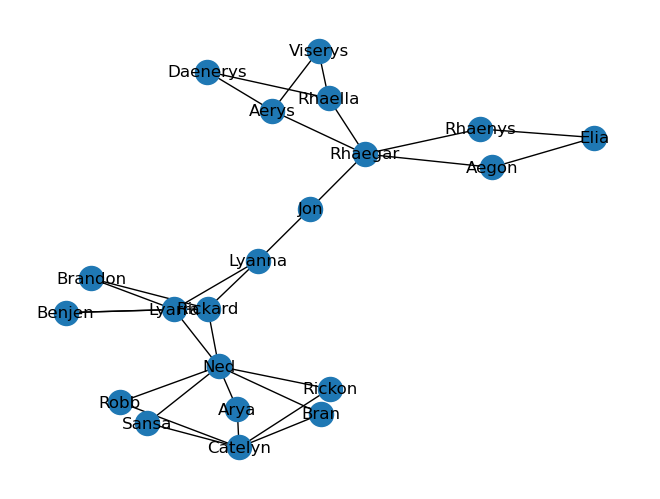

In [6]:
stark_targaryen = ['Rickard','Lyarra','Aerys','Rhaella','Catelyn','Ned','Lyanna','Rhaegar','Elia','Viserys','Daenerys',
                   'Brandon', 'Benjen', 'Robb', 'Sansa', 'Arya', 'Bran', 'Rickon', 'Rhaenys', 'Aegon','Jon']

parents = [('Rickard','Ned'),('Rickard','Lyanna'),('Rickard','Brandon'),('Rickard','Benjen'),
           ('Lyarra','Ned'),('Lyarra','Lyanna'),('Lyarra','Brandon'),('Lyarra','Benjen'),
           ('Aerys','Rhaegar'),('Aerys','Viserys'),('Aerys','Daenerys'),
           ('Rhaella','Rhaegar'),('Rhaella','Viserys'),('Rhaella','Daenerys'),
           ('Catelyn','Robb'),('Catelyn','Sansa'), ('Catelyn','Arya'), ('Catelyn','Bran'), ('Catelyn','Rickon'),
           ('Ned','Robb'),('Ned','Sansa'), ('Ned','Arya'), ('Ned','Bran'), ('Ned','Rickon'),
           ('Rhaegar','Rhaenys'), ('Rhaegar','Aegon'),('Elia','Rhaenys'), ('Elia','Aegon'),
           ('Lyanna','Jon'),('Rhaegar','Jon')]

G.add_nodes_from(stark_targaryen)
G.add_edges_from(parents)

layout=nx.kamada_kawai_layout(G)
nx.draw(G,layout, with_labels=True)

Podemos comparar las distintas centralidades mediante la siguiente figura.

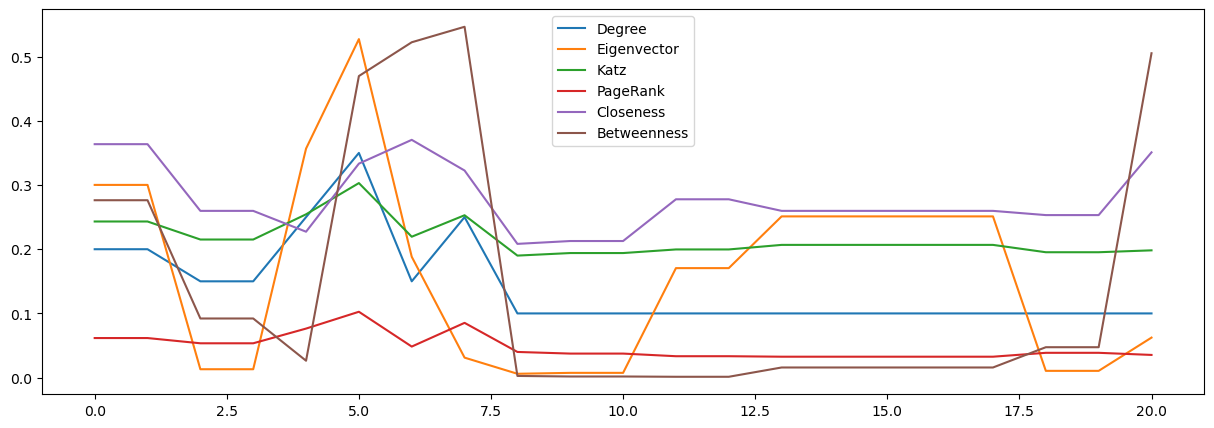

In [4]:
diccionario = nx.degree_centrality(G)
d = np.array([diccionario[i] for i in G])

diccionario = nx.eigenvector_centrality(G)
e = np.array([diccionario[i] for i in G])

diccionario = nx.katz_centrality(G)
k = np.array([diccionario[i] for i in G])

diccionario = nx.pagerank(G)
p = np.array([diccionario[i] for i in G])

diccionario = nx.closeness_centrality(G)
c = np.array([diccionario[i] for i in G])

diccionario = nx.betweenness_centrality(G)
b = np.array([diccionario[i] for i in G])


plt.figure(figsize = [15, 5])
plt.plot(d, label = 'Degree')
plt.plot(e, label = 'Eigenvector')
plt.plot(k, label = 'Katz')
plt.plot(p, label = 'PageRank')
plt.plot(c, label = 'Closeness')
plt.plot(b, label = 'Betweenness')


plt.legend()

Podemos observar que hay nodos que son importantes en varias medidas de centralidad y algunos que son importantes en una medida en específica.

Un histograma de grados nos ayuda a ver la distribución de grados de la red, saber cuántos nodos tienen cierto grado.

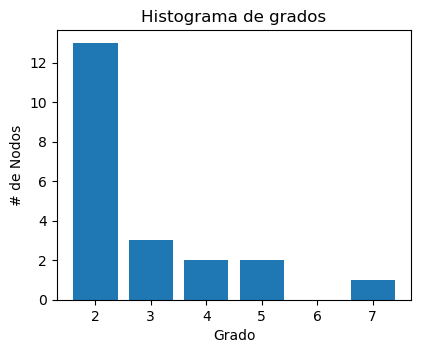

In [7]:
fig = plt.figure("Grados de la red", figsize=(8, 8))
axgrid = fig.add_gridspec(5, 4)

degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Grados de la red", figsize=(8, 8))

ax = fig.add_subplot(axgrid[3:, 2:])
ax.bar(*np.unique(degree_sequence, return_counts=True))
ax.set_title("Histograma de grados")
ax.set_xlabel("Grado")
ax.set_ylabel("# de Nodos")

fig.tight_layout()
plt.show()

## Aves

Cargamos el archivo de la red de aves y creamos la red.

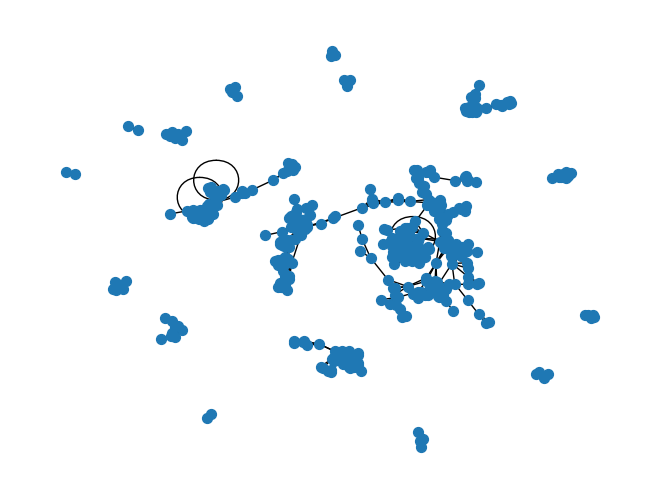

In [8]:
aves =pd.read_csv('aves-weaver-social.edges', header = None, sep=' ')
G=nx.from_pandas_edgelist(aves, source = 0, target = 1)
nx.draw(G, node_size = 50)

Podemos comparar las centralidades de la red

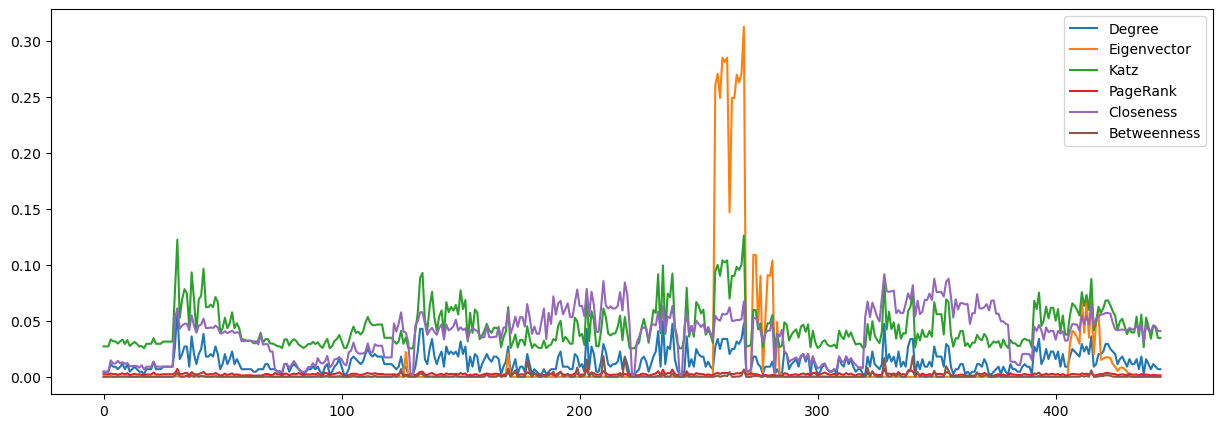

In [9]:
diccionario = nx.degree_centrality(G)
d = np.array([diccionario[i] for i in G])

diccionario = nx.eigenvector_centrality(G)
e = np.array([diccionario[i] for i in G])

diccionario = nx.katz_centrality(G,alpha=0.06)
k = np.array([diccionario[i] for i in G])

diccionario = nx.pagerank(G)
p = np.array([diccionario[i] for i in G])

diccionario = nx.closeness_centrality(G)
c = np.array([diccionario[i] for i in G])

diccionario = nx.betweenness_centrality(G)
b = np.array([diccionario[i] for i in G])


plt.figure(figsize = [15, 5])
plt.plot(d, label = 'Degree')
plt.plot(e, label = 'Eigenvector')
plt.plot(k, label = 'Katz')
plt.plot(p, label = 'PageRank')
plt.plot(c, label = 'Closeness')
plt.plot(b, label = 'Betweenness')


plt.legend()

Nuevamente podemos observar los picos en donde están situados los nodos de mayor centralidad respecto a varias medidas.

Hacemos un histograma de distribución de grados.

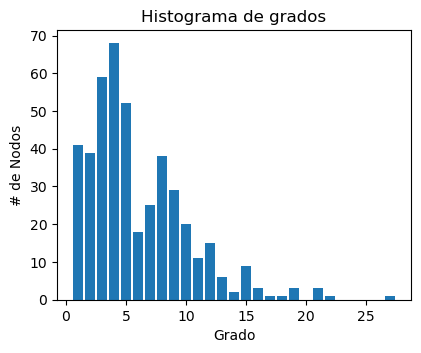

In [10]:
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Grados de la red", figsize=(8, 8))

ax = fig.add_subplot(axgrid[3:, 2:])
ax.bar(*np.unique(degree_sequence, return_counts=True))
ax.set_title("Histograma de grados")
ax.set_xlabel("Grado")
ax.set_ylabel("# de Nodos")

fig.tight_layout()
plt.show()

## Colaboración académica

Cargamos los datos y creamos la red de colaboración entre científicos.

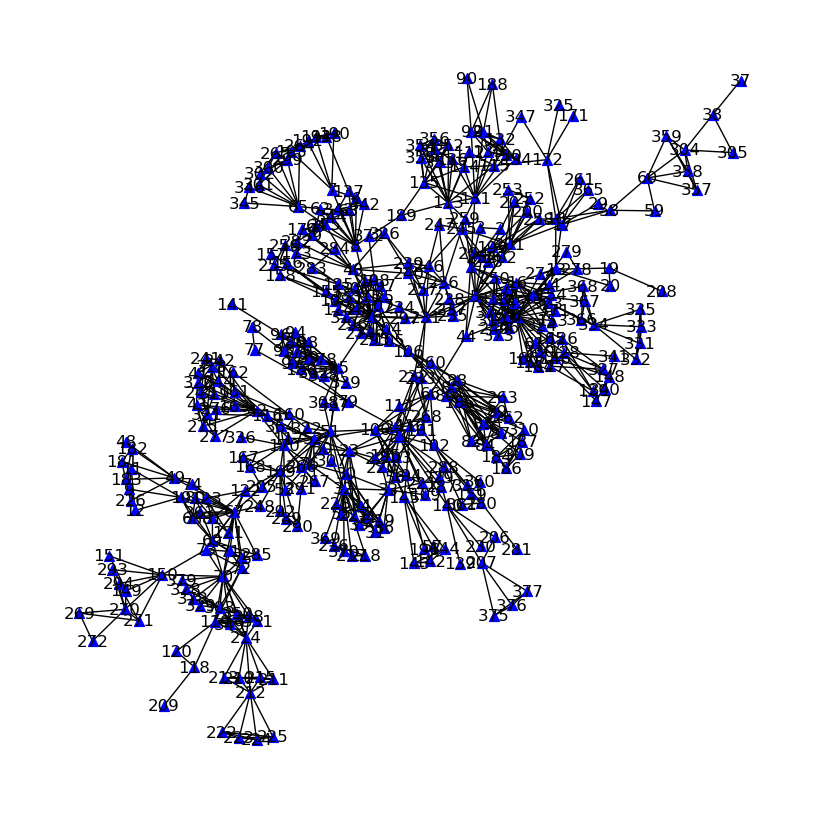

In [11]:
datos = pd.read_csv('ca-netscience.mtx', skiprows = 2, header = None,sep = ' ')
aristas = datos[[0,1]].values
G = nx.Graph()
G.add_edges_from(aristas)

plt.figure( figsize = [8,8] )
layout=nx.kamada_kawai_layout(G)
nx.draw(G,layout, with_labels=True, node_size = 50, node_color = 'b',node_shape = '^') 

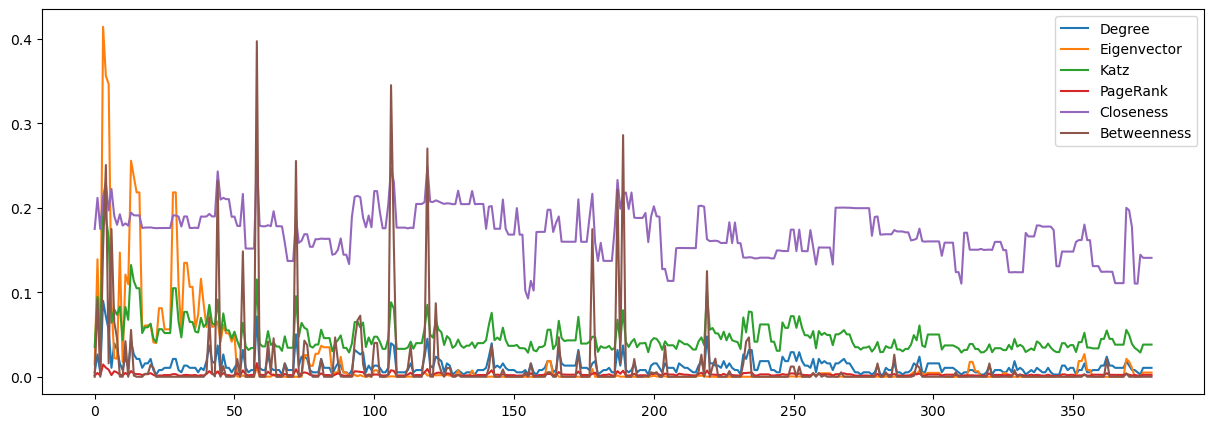

In [12]:
diccionario = nx.degree_centrality(G)
d = np.array([diccionario[i] for i in G])

diccionario = nx.eigenvector_centrality(G)
e = np.array([diccionario[i] for i in G])

diccionario = nx.katz_centrality(G,alpha=0.07)
k = np.array([diccionario[i] for i in G])

diccionario = nx.pagerank(G)
p = np.array([diccionario[i] for i in G])

diccionario = nx.closeness_centrality(G)
c = np.array([diccionario[i] for i in G])

diccionario = nx.betweenness_centrality(G)
b = np.array([diccionario[i] for i in G])


plt.figure(figsize = [15, 5])
plt.plot(d, label = 'Degree')
plt.plot(e, label = 'Eigenvector')
plt.plot(k, label = 'Katz')
plt.plot(p, label = 'PageRank')
plt.plot(c, label = 'Closeness')
plt.plot(b, label = 'Betweenness')


plt.legend()

Vemos el histograma de grados.

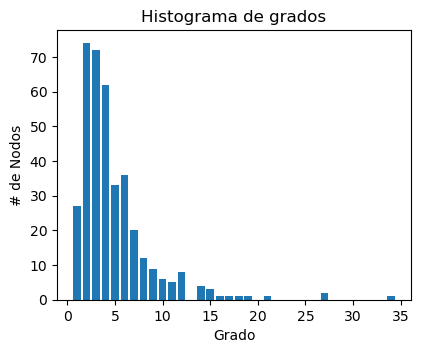

In [13]:
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)

fig = plt.figure("Grados de la red", figsize=(8, 8))

ax = fig.add_subplot(axgrid[3:, 2:])
ax.bar(*np.unique(degree_sequence, return_counts=True))
ax.set_title("Histograma de grados")
ax.set_xlabel("Grado")
ax.set_ylabel("# de Nodos")

fig.tight_layout()
plt.show()